In [106]:
import pandas as pd
import networkx_temporal as tx
import numpy as np
import graph_tool.all as gt

# STI spreading on network

- Behavior_1: Anal sex with/without condom?  (Yes: +1, No: -1, Information not available: 0)  
- Behavior_2: Oral sex with condom?          (Yes: +1, No: -1, Information not available: 0)  
- Behavior_3: Mouth kiss?                    (Yes: +1, No: -1, Information not available: 0)  

In [107]:
column_names = [
    "Female_id",
    "Male_id",
    "Date_days",
    "Grade",
    "Behavoir_1",
    "Behavior_2",
    "Behavior_3"
]

df_sex_contacts = pd.read_csv(
    'Datasets/pcbi.1001109.s001.csv',
    comment='#',
    sep=';',
    names=column_names
)

In [108]:
df_sex_contacts

,Female_id,Male_id,Date_days,Grade,Behavoir_1,Behavior_2,Behavior_3
0,0,1,0,0,0,0,0
1,2,1,0,1,-1,1,-1
2,3,1,0,0,0,0,0
3,0,4,21,0,0,0,0
4,5,6,47,0,0,0,0
...,...,...,...,...,...,...,...
50627,16724,13831,2231,0,-1,1,1
50628,16725,14958,2231,1,0,1,1
50629,16368,10049,2232,1,-1,1,1
50630,16726,16727,2232,1,1,1,1


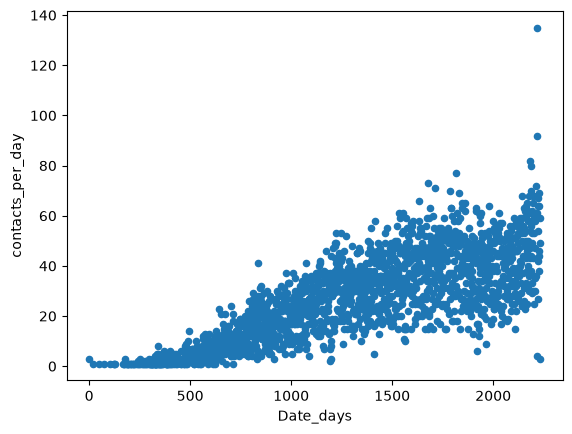

In [109]:
df_daily_contacts = df_sex_contacts.groupby('Date_days').size().reset_index(name='contacts_per_day')
df_daily_contacts.plot(x='Date_days', y='contacts_per_day', kind='scatter');

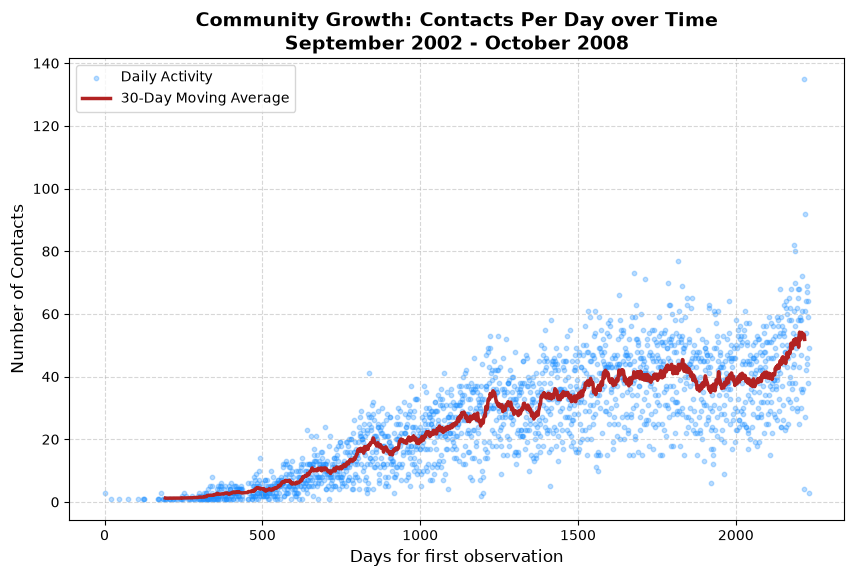

In [110]:
import matplotlib.pyplot as plt

# 1. Calculate a 30-day rolling average to smooth the data
df_daily_contacts['rolling_30'] = df_daily_contacts['contacts_per_day'].rolling(window=30, center=True).mean()

plt.figure(figsize=(10, 6))

# Plot the original data faintly in the background
plt.scatter(df_daily_contacts['Date_days'], df_daily_contacts['contacts_per_day'], 
            alpha=0.3, color='dodgerblue', s=10, label='Daily Activity')

# Overlay the clean trend line
plt.plot(df_daily_contacts['Date_days'], df_daily_contacts['rolling_30'], 
         color='firebrick', linewidth=2.5, label='30-Day Moving Average')

plt.title('Community Growth: Contacts Per Day over Time\nSeptember 2002 - October 2008', fontsize=14, fontweight='bold')
plt.xlabel('Days for first observation', fontsize=12)
plt.ylabel('Number of Contacts', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Check power law distribution

In [111]:
# add months count

bins = np.arange(0, 2260, 30)
labels = np.arange(1, len(bins))
df_sex_contacts["Month_count"] = pd.cut(
    df_sex_contacts["Date_days"], bins=bins, labels=labels, right=False
)
df_sex_contacts["Month_count"] = df_sex_contacts["Month_count"].astype(int)
df_sex_contacts

,Female_id,Male_id,Date_days,Grade,Behavoir_1,Behavior_2,Behavior_3,Month_count
0,0,1,0,0,0,0,0,1
1,2,1,0,1,-1,1,-1,1
2,3,1,0,0,0,0,0,1
3,0,4,21,0,0,0,0,1
4,5,6,47,0,0,0,0,2
...,...,...,...,...,...,...,...,...
50627,16724,13831,2231,0,-1,1,1,75
50628,16725,14958,2231,1,0,1,1,75
50629,16368,10049,2232,1,-1,1,1,75
50630,16726,16727,2232,1,1,1,1,75


In [112]:
df_sex_contacts[df_sex_contacts['Month_count'] == 75]

,Female_id,Male_id,Date_days,Grade,Behavoir_1,Behavior_2,Behavior_3,Month_count
50006,11194,16470,2220,1,1,1,1,75
50007,12115,16545,2220,1,1,1,1,75
50008,12115,1879,2220,1,1,1,1,75
50009,11538,12080,2220,1,-1,1,1,75
50010,11545,1468,2220,1,1,1,1,75
...,...,...,...,...,...,...,...,...
50627,16724,13831,2231,0,-1,1,1,75
50628,16725,14958,2231,1,0,1,1,75
50629,16368,10049,2232,1,-1,1,1,75
50630,16726,16727,2232,1,1,1,1,75


Define a temporal network.

In [ ]:
# Build weighted edgelist: one entry per unique (Female_id, Male_id, Month_count)
# Weight = number of contacts between that pair within the same month
df_weighted = (
    df_sex_contacts
    .groupby(['Female_id', 'Male_id', 'Month_count'])
    .size()
    .reset_index(name='weight')
)

G = gt.Graph(directed=False)

unique_ids = np.unique(np.concatenate([df_sex_contacts['Female_id'], df_sex_contacts['Male_id']]))
id_to_vertex = {original_id: G.add_vertex() for original_id in unique_ids}

v_id_map = G.new_vertex_property("int")
for original_id, vertex in id_to_vertex.items():
    v_id_map[vertex] = original_id
G.vertex_properties["original_id"] = v_id_map

ep_month  = G.new_edge_property("int")
ep_weight = G.new_edge_property("int")

for _, row in df_weighted.iterrows():
    u = id_to_vertex[row['Female_id']]
    v = id_to_vertex[row['Male_id']]
    e = G.add_edge(u, v)
    ep_month[e]  = row['Month_count']
    ep_weight[e] = row['weight']

G.edge_properties["month"]  = ep_month
G.edge_properties["weight"] = ep_weight

print(f"Weighted graph: {G.num_vertices()} nodes, {G.num_edges()} unique temporal edges")
print(f"Original contact rows: {len(df_sex_contacts)}, unique (pair, month) edges: {len(df_weighted)}")
print(df_weighted[df_weighted['weight'] > 1].head(5))

In [114]:
import powerlaw
from collections import Counter

snapshots = sorted(df_sex_contacts['Month_count'].unique())
results = []

for month in snapshots:
    df_snap = df_sex_contacts[df_sex_contacts['Month_count'] == month]

    # Degree of each node = number of contacts in this snapshot
    degree_counter = Counter()
    degree_counter.update(df_snap['Female_id'])
    degree_counter.update(df_snap['Male_id'])
    degrees = list(degree_counter.values())

    if len(degrees) < 10:
        continue

    fit = powerlaw.Fit(degrees, discrete=True, verbose=False)
    results.append({
        'month':   month,
        'n_nodes': len(degrees),
        'n_edges': len(df_snap),
        'alpha':   fit.power_law.alpha,
        'xmin':    fit.power_law.xmin,
    })

df_results = pd.DataFrame(results)
df_results.head(10)

/opt/anaconda3/envs/sfi_sti_model/lib/python3.14/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
/opt/anaconda3/envs/sfi_sti_model/lib/python3.14/site-packages/powerlaw.py:699: RuntimeWarning: divide by zero encountered in divide
  (CDF_diff**2) /


,month,n_nodes,n_edges,alpha,xmin
0,6,10,6,2.202246,1.0
1,7,15,8,2.352527,1.0
2,9,17,12,2.021909,1.0
3,10,22,13,2.220742,1.0
4,11,48,34,3.364977,2.0
5,12,74,55,3.203958,2.0
6,13,84,63,4.834645,3.0
7,14,112,89,3.127218,3.0
8,15,70,48,2.790633,2.0
9,16,91,72,2.698979,2.0


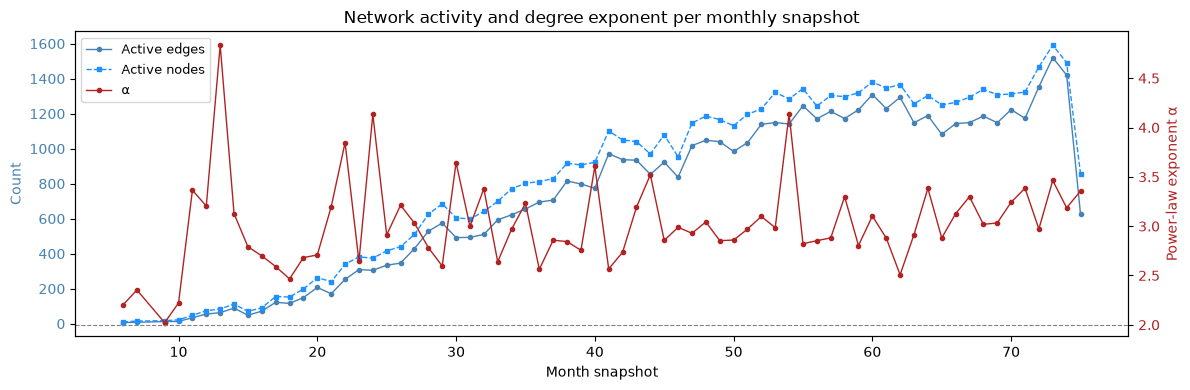

 month  n_nodes  n_edges    alpha  xmin
     6       10        6 2.202246   1.0
     7       15        8 2.352527   1.0
     9       17       12 2.021909   1.0
    10       22       13 2.220742   1.0
    11       48       34 3.364977   2.0
    12       74       55 3.203958   2.0
    13       84       63 4.834645   3.0
    14      112       89 3.127218   3.0
    15       70       48 2.790633   2.0
    16       91       72 2.698979   2.0
    17      155      122 2.590491   2.0
    18      152      116 2.465408   2.0
    19      198      149 2.681253   3.0
    20      263      207 2.707970   2.0
    21      240      171 3.195501   3.0
    22      339      253 3.845889   4.0
    23      382      309 2.644062   2.0
    24      374      305 4.133165   9.0
    25      416      334 2.911374   3.0
    26      440      346 3.212478   3.0
    27      510      429 3.030804   3.0
    28      625      528 2.782842   2.0
    29      685      575 2.596219   2.0
    30      605      492 3.643698   5.0


In [115]:
fig, ax1 = plt.subplots(figsize=(12, 4))

ax1.plot(df_results['month'], df_results['n_edges'], color='steelblue', marker='o',
         markersize=3, linewidth=1, label='Active edges')
ax1.plot(df_results['month'], df_results['n_nodes'], color='dodgerblue', marker='s',
         markersize=3, linewidth=1, linestyle='--', label='Active nodes')
ax1.set_xlabel('Month snapshot')
ax1.set_ylabel('Count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(df_results['month'], df_results['alpha'], color='firebrick', marker='o',
         markersize=3, linewidth=1, label='α')
ax2.axhline(2.0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Power-law exponent α', color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.title('Network activity and degree exponent per monthly snapshot')
plt.tight_layout()
plt.show()

print(df_results[['month', 'n_nodes', 'n_edges', 'alpha', 'xmin']].to_string(index=False))

<>:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/q_/n08xblxj1bq8yczcg1l1p1t40000gn/T/ipykernel_21288/3259485550.py:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  ax.set_ylabel('$P(K \geq k)$', fontsize=12)
/opt/anaconda3/envs/sfi_sti_model/lib/python3.14/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
/opt/anaconda3/envs/sfi_sti_model/lib/python3.14/site-packages/powerlaw.py:699: RuntimeWarning: divide by zero encountered in divide
  (CDF_diff**2) /


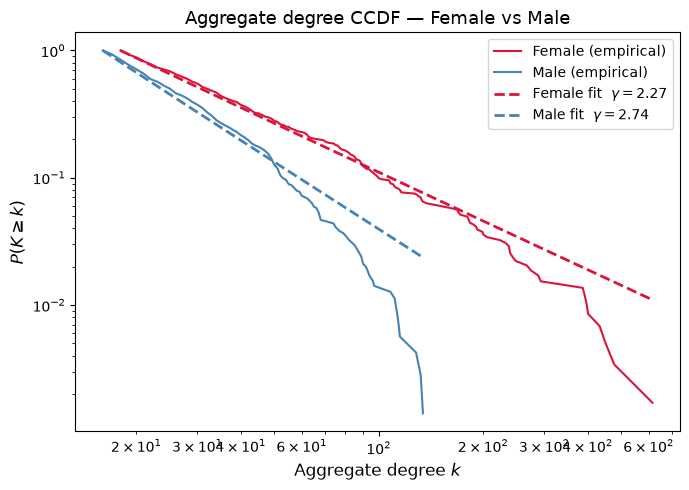

In [116]:
female_ids = set(df_sex_contacts['Female_id'].unique())
male_ids   = set(df_sex_contacts['Male_id'].unique())

# Aggregate degree = total contacts across all snapshots
agg_degree_female = df_sex_contacts.groupby('Female_id').size().values
agg_degree_male   = df_sex_contacts.groupby('Male_id').size().values

# Keep only nodes with at least one contact
agg_degree_female = agg_degree_female[agg_degree_female > 0]
agg_degree_male   = agg_degree_male[agg_degree_male > 0]

# Power-law fits
fit_f = powerlaw.Fit(agg_degree_female, discrete=True, verbose=False)
fit_m = powerlaw.Fit(agg_degree_male,   discrete=True, verbose=False)

alpha_f = fit_f.power_law.alpha
alpha_m = fit_m.power_law.alpha

fig, ax = plt.subplots(figsize=(7, 5))

# Empirical CCDFs
fit_f.plot_ccdf(ax=ax, color='crimson',   linewidth=1.5, label='Female (empirical)')
fit_m.plot_ccdf(ax=ax, color='steelblue', linewidth=1.5, label='Male (empirical)')

# Power-law fit overlays
fit_f.power_law.plot_ccdf(ax=ax, color='crimson',   linewidth=2, linestyle='--',
                           label=fr'Female fit  $\gamma = {alpha_f:.2f}$')
fit_m.power_law.plot_ccdf(ax=ax, color='steelblue', linewidth=2, linestyle='--',
                           label=fr'Male fit  $\gamma = {alpha_m:.2f}$')

ax.set_xlabel('Aggregate degree $k$', fontsize=12)
ax.set_ylabel('$P(K \geq k)$', fontsize=12)
ax.set_title('Aggregate degree CCDF — Female vs Male', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

<>:24: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:24: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/q_/n08xblxj1bq8yczcg1l1p1t40000gn/T/ipykernel_21288/3353910832.py:24: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  ax.set_ylabel('$P(K{\geq}k)$', fontsize=7)


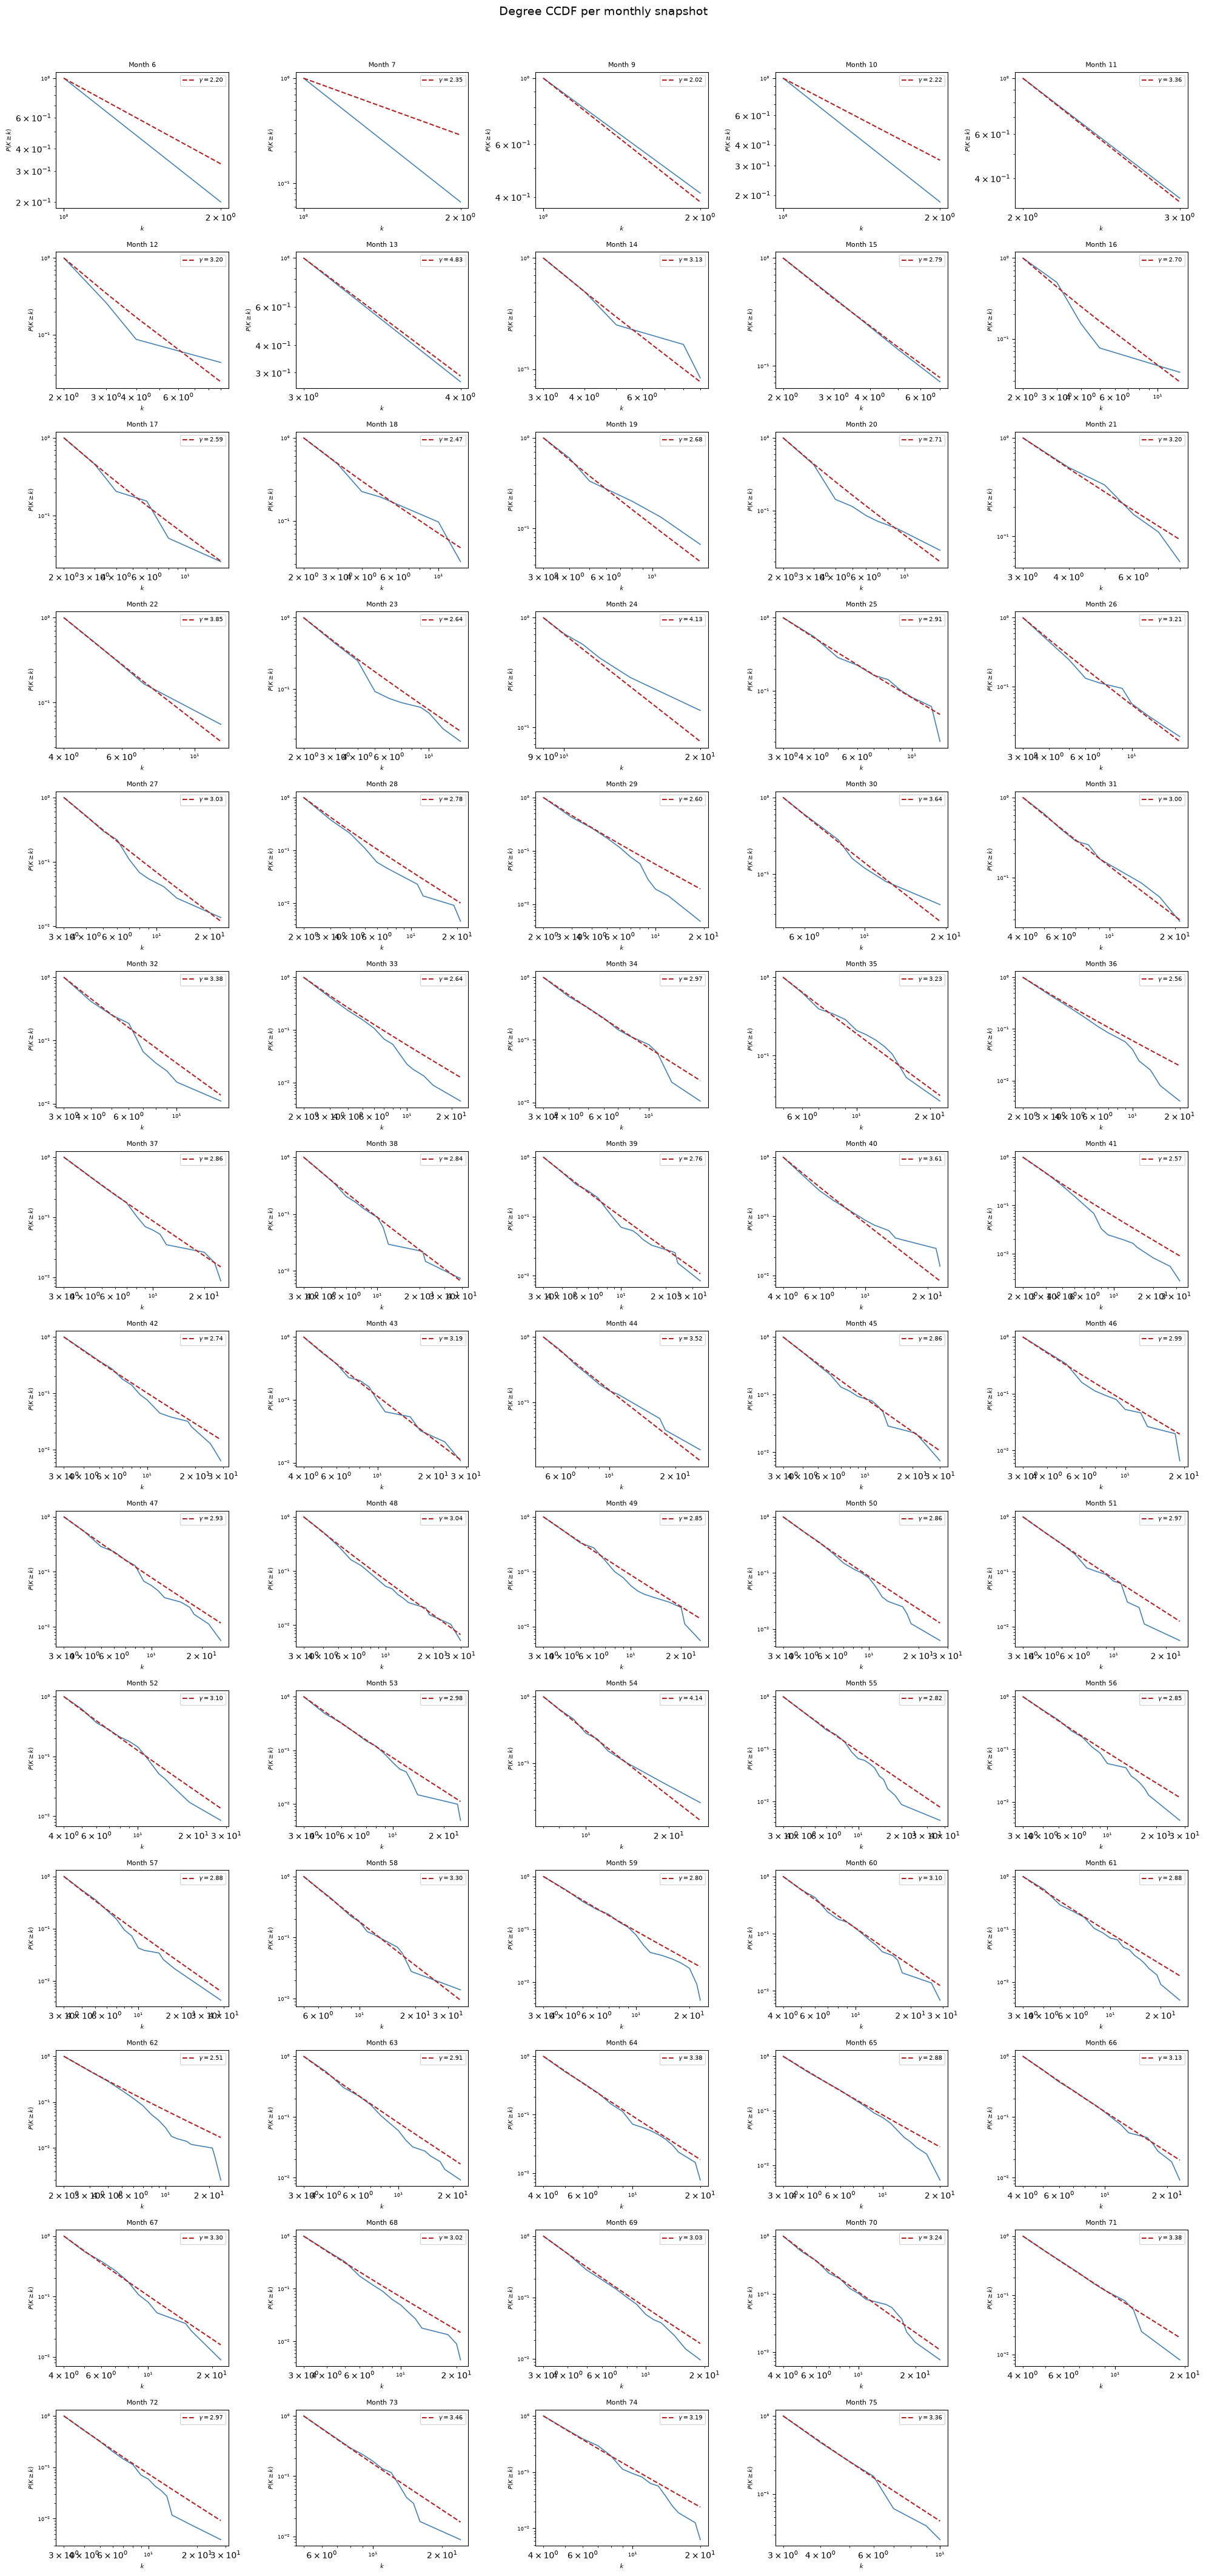

In [117]:
n_cols = 5
n_rows = int(np.ceil(len(df_results) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for ax, (_, row) in zip(axes, df_results.iterrows()):
    month  = int(row['month'])
    df_snap = df_sex_contacts[df_sex_contacts['Month_count'] == month]

    degree_counter = Counter()
    degree_counter.update(df_snap['Female_id'])
    degree_counter.update(df_snap['Male_id'])
    degrees = list(degree_counter.values())

    fit = powerlaw.Fit(degrees, discrete=True, verbose=False)
    fit.plot_ccdf(ax=ax, color='steelblue', linewidth=1.2)
    fit.power_law.plot_ccdf(ax=ax, color='firebrick', linewidth=1.5,
                             linestyle='--',
                             label=fr'$\gamma={fit.power_law.alpha:.2f}$')

    ax.set_title(f'Month {month}', fontsize=8)
    ax.set_xlabel('$k$', fontsize=7)
    ax.set_ylabel('$P(K{\geq}k)$', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=7)

# Hide unused axes
for ax in axes[len(df_results):]:
    ax.set_visible(False)

plt.suptitle('Degree CCDF per monthly snapshot', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Weight distribution

In [ ]:
# Aggregate weight: sum contacts per unique (Female_id, Male_id) pair across all months
df_agg_weights = (
    df_sex_contacts
    .groupby(['Female_id', 'Male_id'])
    .size()
    .reset_index(name='weight')
)
agg_weights = df_agg_weights['weight'].values

fit_w = powerlaw.Fit(agg_weights, discrete=True, verbose=False)

fig, ax = plt.subplots(figsize=(6, 4))
fit_w.plot_ccdf(ax=ax, color='steelblue', linewidth=1.5, label='Empirical')
fit_w.power_law.plot_ccdf(ax=ax, color='firebrick', linewidth=2, linestyle='--',
                           label=fr'Power-law fit  $\gamma={fit_w.power_law.alpha:.2f}$')
ax.set_xlabel('Aggregate edge weight $w$', fontsize=12)
ax.set_ylabel('$P(W \geq w)$', fontsize=12)
ax.set_title('Aggregate weight CCDF (all snapshots combined)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Max weight: {agg_weights.max()},  Mean: {agg_weights.mean():.2f},  '
      f'Fraction w=1: {(agg_weights==1).mean():.2%}')


In [ ]:
# Per-snapshot weight distribution — one panel per month
snap_weights = (
    df_sex_contacts
    .groupby(['Female_id', 'Male_id', 'Month_count'])
    .size()
    .reset_index(name='weight')
)

valid_months = [m for m in sorted(df_sex_contacts['Month_count'].unique())
                if (snap_weights[snap_weights['Month_count'] == m]['weight'].nunique() > 1
                    or len(snap_weights[snap_weights['Month_count'] == m]) >= 10)]

n_cols = 5
n_rows = int(np.ceil(len(valid_months) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for ax, month in zip(axes, valid_months):
    w = snap_weights[snap_weights['Month_count'] == month]['weight'].values
    if len(w) < 5:
        ax.set_visible(False)
        continue
    # Simple CCDF without powerlaw fit when all weights are 1
    if w.max() == 1:
        ax.step([1, 2], [1, 0], color='steelblue', linewidth=1.2)
        ax.set_title(f'Month {month}\n(all w=1)', fontsize=7)
    else:
        fit_w = powerlaw.Fit(w, discrete=True, verbose=False)
        fit_w.plot_ccdf(ax=ax, color='steelblue', linewidth=1.2)
        fit_w.power_law.plot_ccdf(ax=ax, color='firebrick', linewidth=1.5, linestyle='--',
                                   label=fr'$\gamma={fit_w.power_law.alpha:.2f}$')
        ax.legend(fontsize=7)
        ax.set_title(f'Month {month}', fontsize=8)
    ax.set_xlabel('$w$', fontsize=7)
    ax.set_ylabel('$P(W{\geq}w)$', fontsize=7)
    ax.tick_params(labelsize=6)

for ax in axes[len(valid_months):]:
    ax.set_visible(False)

plt.suptitle('Edge weight CCDF per monthly snapshot', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# Epidemic modelling

Doubts:
- Assignation of initial spreaders should be based on data.
- How many simulations

In [118]:
def assign_transmission_rates(df_contacts, criterion='random',
                               beta_low=0.1, beta_high=0.75,
                               high_degree_fraction=0.20):
    """
    Assign a transmission rate to every node in the dataset.

    Parameters
    ----------
    df_contacts : DataFrame
        Full contact dataframe with Female_id, Male_id columns.
    criterion : str
        'random'     — high/low assigned at random
        'high_to_hub' — high beta assigned to high-degree nodes (top fraction)
        'high_to_low' — high beta assigned to low-degree nodes (bottom fraction)
    beta_low : float
        Transmission rate for low-beta nodes.
    beta_high : float
        Transmission rate for high-beta nodes.
    high_degree_fraction : float
        Fraction of nodes considered high-degree (default 0.20 → top 20%).

    Returns
    -------
    dict : node_id -> beta
    """
    # Aggregate degree across all snapshots
    agg_degree = Counter()
    agg_degree.update(df_contacts['Female_id'])
    agg_degree.update(df_contacts['Male_id'])

    all_nodes = np.array(list(agg_degree.keys()))
    degrees   = np.array([agg_degree[n] for n in all_nodes])

    # Threshold: top high_degree_fraction are "hubs"
    threshold = np.quantile(degrees, 1.0 - high_degree_fraction)
    is_hub    = degrees >= threshold

    if criterion == 'random':
        high_mask = np.random.rand(len(all_nodes)) < high_degree_fraction

    elif criterion == 'high_to_hub':
        high_mask = is_hub

    elif criterion == 'high_to_low':
        high_mask = ~is_hub

    else:
        raise ValueError(f"criterion must be 'random', 'high_to_hub', or 'high_to_low'. Got '{criterion}'.")

    beta_map = {
        node: (beta_high if h else beta_low)
        for node, h in zip(all_nodes, high_mask)
    }
    return beta_map

In [ ]:
def run_SI_simulations(df_contacts, beta_map,
                       n_simulations=100, n_seeds=3):
    """
    Run multiple SI epidemic simulations on the weighted temporal network.

    Transmission probability for an edge (u→v) in snapshot t:
        p = min(1, weight(u,v,t) * beta(u))

    Parameters
    ----------
    df_contacts : DataFrame
        Full contact dataframe with Female_id, Male_id, Month_count.
    beta_map : dict
        node_id -> base transmission rate (from assign_transmission_rates).
    n_simulations : int
        Number of independent simulations to run.
    n_seeds : int
        Number of randomly chosen infected nodes at snapshot 1.

    Returns
    -------
    infected_counts : np.ndarray, shape (n_simulations, n_snapshots)
    snapshots : list
    """
    snapshots = sorted(df_contacts['Month_count'].unique())
    all_nodes = list(set(df_contacts['Female_id']) | set(df_contacts['Male_id']))

    # Pre-build weighted edge list per snapshot: month -> list of (u, v, weight)
    df_w = (
        df_contacts
        .groupby(['Female_id', 'Male_id', 'Month_count'])
        .size()
        .reset_index(name='weight')
    )
    edges_by_month = {
        month: list(zip(grp['Female_id'], grp['Male_id'], grp['weight']))
        for month, grp in df_w.groupby('Month_count')
    }

    infected_counts = np.zeros((n_simulations, len(snapshots)), dtype=int)

    for sim in range(n_simulations):
        infected = set(np.random.choice(all_nodes, size=n_seeds, replace=False))

        for t, month in enumerate(snapshots):
            new_infected = set()
            for u, v, w in edges_by_month.get(month, []):
                if u in infected and v not in infected:
                    if np.random.rand() < min(1.0, w * beta_map.get(u, 0.1)):
                        new_infected.add(v)
                if v in infected and u not in infected:
                    if np.random.rand() < min(1.0, w * beta_map.get(v, 0.1)):
                        new_infected.add(u)

            infected |= new_infected
            infected_counts[sim, t] = len(infected)

    return infected_counts, snapshots

In [122]:
# Run 100 simulations for each assignment criterion
criteria = ['random', 'high_to_hub', 'high_to_low']
sim_results = {}

for criterion in criteria:
    beta_map = assign_transmission_rates(df_sex_contacts, criterion=criterion)
    counts, snapshots = run_SI_simulations(df_sex_contacts, beta_map, n_simulations=1000)
    sim_results[criterion] = counts

print("Simulations complete.")

Simulations complete.


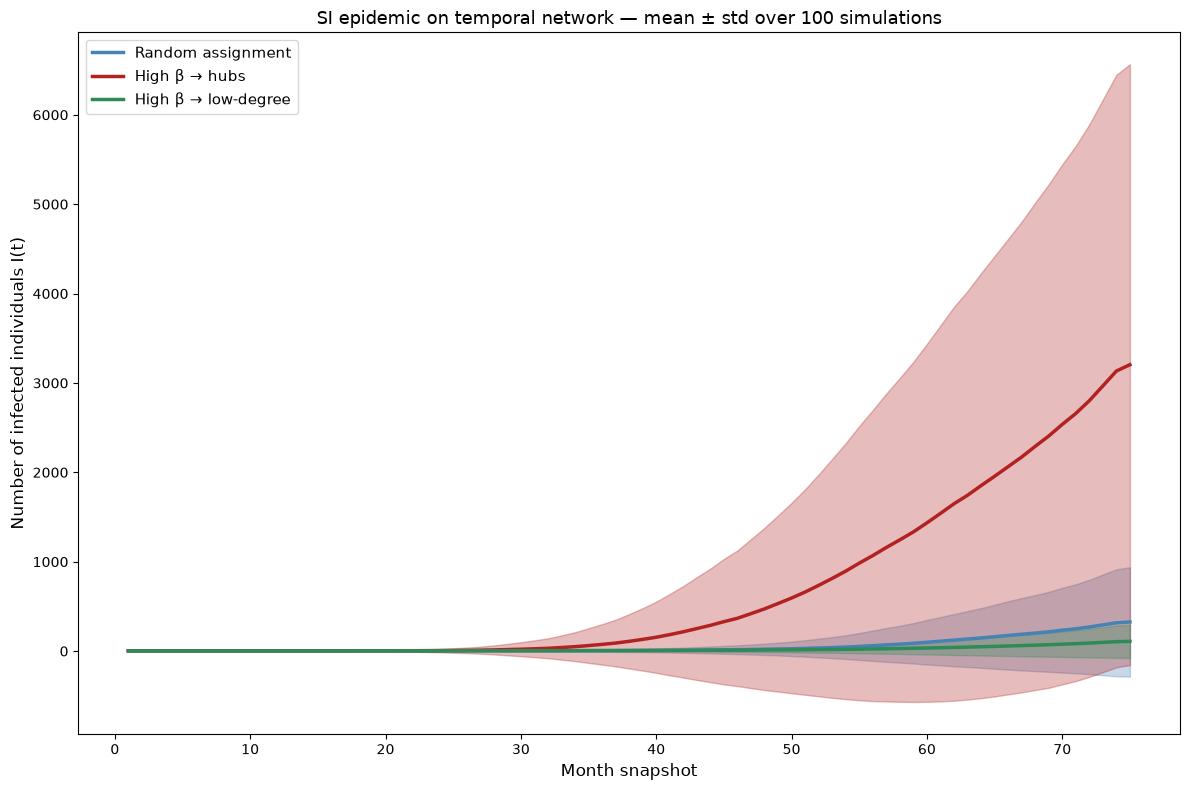

In [128]:
colors = {
    'random':      'steelblue',
    'high_to_hub': 'firebrick',
    'high_to_low': 'seagreen',
}
labels = {
    'random':      'Random assignment',
    'high_to_hub': 'High β → hubs',
    'high_to_low': 'High β → low-degree',
}

fig, ax = plt.subplots(figsize=(12, 8))

for criterion, counts in sim_results.items():
    mean = counts.mean(axis=0)
    std  = counts.std(axis=0)
    color = colors[criterion]

    ax.plot(snapshots, mean, linewidth=2.5, color=color, label=labels[criterion])
    ax.fill_between(snapshots, mean - std, mean + std, color=color, alpha=0.3)

ax.set_xlabel('Month snapshot', fontsize=12)
ax.set_ylabel('Number of infected individuals I(t)', fontsize=12)
ax.set_title('SI epidemic on temporal network — mean ± std over 100 simulations', fontsize=13)
# ax.set_yscale('log')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()